# Customer Sentiment Analysis
### Twitter US Airline Sentiment — End-to-End Case Study

**Business context.** Businesses with a public social media presence generate
a constant stream of customer feedback they rarely have time to systematically
read. This notebook builds a pipeline that automatically classifies customer
sentiment, identifies *why* customers are unhappy (not just that they are),
and benchmarks brands against each other — the kind of analysis a business
would otherwise pay a social-listening tool a monthly subscription for.

This notebook answers five core business questions:

1. What's the overall sentiment split, and does a simple rule-based approach
   (no training data needed) get close to a trained model?
2. Which machine learning approach classifies sentiment most accurately?
3. What specific words/phrases drive negative vs. positive sentiment?
4. Which brand (airline) is underperforming its peers, and why?
5. What's the single biggest driver of customer complaints?

**Dataset.** Public Twitter US Airline Sentiment dataset — 14,640 tweets
about six major US airlines (United, US Airways, American, Southwest, Delta,
Virgin America), collected February 2015, each hand-labeled positive,
neutral, or negative, with negative tweets further labeled by *reason*
(customer service, late flight, lost luggage, etc.).

**Deliverable.** A single, fully-executable notebook — text cleaning through
five different classification approaches — with every result paired with a
plain-English business interpretation, matching consulting/portfolio standard.


## Module 1 — Setup

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

import nltk
nltk.download("vader_lexicon", quiet=True)


True

## Module 2 — Data Understanding

In [2]:
df = pd.read_csv("data/Tweets.csv")
df = df[["airline_sentiment", "airline", "negativereason", "text"]].copy()
print(df.shape)
df.head()


(14640, 4)


,airline_sentiment,airline,negativereason,text
0,neutral,Virgin America,NaN,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,NaN,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,NaN,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,Bad Flight,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,Can't Tell,@VirginAmerica and it's a really big bad thing...


## Module 3 — Data Quality Assessment

In [3]:
print("Missing text/sentiment:", df[["text", "airline_sentiment"]].isna().sum().sum())
print("Duplicate tweets:", df["text"].duplicated().sum())
print("\nSentiment classes:", df["airline_sentiment"].unique())
print("\nAirlines covered:", df["airline"].unique())


Missing text/sentiment: 0
Duplicate tweets: 213

Sentiment classes: <ArrowStringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Airlines covered: <ArrowStringArray>
['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways', 'American']
Length: 6, dtype: str


In [4]:
df = df.dropna(subset=["text", "airline_sentiment"]).copy()
df = df.drop_duplicates(subset="text")
print(f"Rows after cleaning: {len(df):,}")


Rows after cleaning: 14,427


## Module 4 — Text Cleaning

Standard social-media text preprocessing: strip @mentions (they're noise for
sentiment, not signal), strip URLs, keep only letters, normalize whitespace.

**Negation handling.** A naive cleaning step turns "wouldn't" into "wouldn
t" — two meaningless fragments that silently destroy the negation entirely.
This is a well-known failure mode for bag-of-words sentiment models: "not
good" and "good" can end up looking identical to the model. Here, contractions
are expanded first ("wouldn't" → "would not"), then a negation word is merged
with the word right after it into a single token ("not good" → "not_good"),
so the model can learn negated phrases as their own feature.


In [5]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    contractions = {
        "won't": "will not", "can't": "can not", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
        "'ve": " have", "'m": " am",
    }
    for k, v in contractions.items():
        text = text.replace(k, v)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\b(not|no|never)\s+(\w+)", r"\1_\2", text)
    return text


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0]

df[["text", "clean_text"]].head()


,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experie...
2,@VirginAmerica I didn't today... Must mean I n...,i did not_today must mean i need to take anoth...
3,@VirginAmerica it's really aggressive to blast...,it is really aggressive to blast obnoxious ent...
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it


## Module 5 — Business EDA (before any modeling)

The most valuable insights in this notebook don't require machine learning
at all — they come straight out of counting and grouping the labeled data.


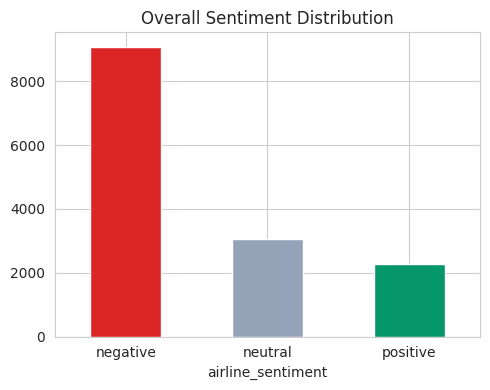

airline_sentiment
negative    62.9
neutral     21.2
positive    15.9
Name: count, dtype: float64


In [6]:
sentiment_counts = df["airline_sentiment"].value_counts()

sentiment_counts.plot(kind="bar", figsize=(5, 4), color=["#DC2626", "#94A3B8", "#059669"])
plt.title("Overall Sentiment Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print((sentiment_counts / len(df) * 100).round(1))


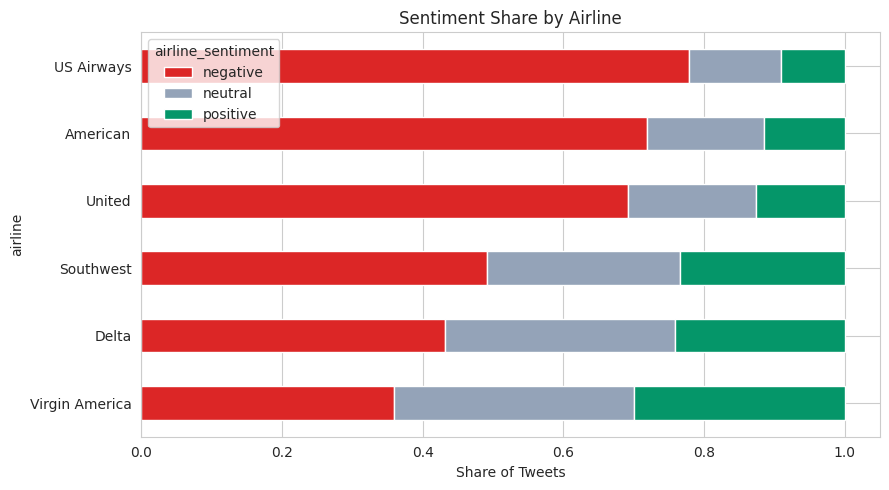

Highest negative-sentiment share: US Airways (77.8%)
Lowest negative-sentiment share:  Virgin America (36.0%)


In [7]:
sentiment_by_airline = pd.crosstab(df["airline"], df["airline_sentiment"], normalize="index")

sentiment_by_airline[["negative", "neutral", "positive"]].sort_values("negative").plot(
    kind="barh", stacked=True, figsize=(9, 5), color=["#DC2626", "#94A3B8", "#059669"]
)
plt.title("Sentiment Share by Airline")
plt.xlabel("Share of Tweets")
plt.tight_layout()
plt.show()

worst_airline = sentiment_by_airline["negative"].idxmax()
best_airline = sentiment_by_airline["negative"].idxmin()
print(f"Highest negative-sentiment share: {worst_airline} ({sentiment_by_airline.loc[worst_airline, 'negative']:.1%})")
print(f"Lowest negative-sentiment share:  {best_airline} ({sentiment_by_airline.loc[best_airline, 'negative']:.1%})")


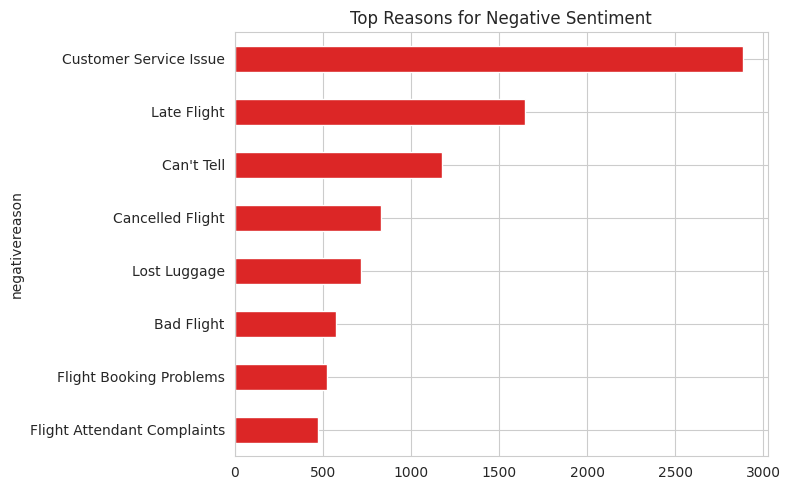

Top complaint driver: 'Customer Service Issue' — 31.8% of all negative tweets


In [8]:
top_negative_reasons = df["negativereason"].value_counts().head(8)

top_negative_reasons.sort_values().plot(kind="barh", figsize=(8, 5), color="#DC2626")
plt.title("Top Reasons for Negative Sentiment")
plt.tight_layout()
plt.show()

top_complaint = top_negative_reasons.index[0]
top_pct = top_negative_reasons.iloc[0] / (df["airline_sentiment"] == "negative").sum() * 100
print(f"Top complaint driver: '{top_complaint}' — {top_pct:.1f}% of all negative tweets")


## Module 6 — VADER: A Rule-Based Baseline (No Training Required)

Before building a trained model, it's worth testing whether a simple,
off-the-shelf, rule-based sentiment tool gets you most of the way there —
this sets a realistic bar for how much value the more expensive, trained
models actually add.


In [9]:
sia = SentimentIntensityAnalyzer()


def vader_label(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"


df["vader_pred"] = df["text"].apply(vader_label)
print("VADER predictions generated (no training data used).")


VADER predictions generated (no training data used).


## Module 7 — Train / Test Split & TF-IDF Vectorization

Stratified split to preserve the class proportions (negative tweets are
~63% of the data — not as extreme as the fraud detection project, but still
meaningfully imbalanced). TF-IDF with unigrams + bigrams captures short
phrases ("customer service", "on time") that single words miss.


In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["airline_sentiment"], test_size=0.25,
    random_state=RANDOM_STATE, stratify=df["airline_sentiment"],
)
vader_test = df.loc[X_test_text.index, "vader_pred"]

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, stop_words="english")
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (10820, 5000), Test: (3607, 5000)


## Module 8 — Model 1: Naive Bayes (TF-IDF)

The classic, fast baseline for text classification.


In [11]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)


## Module 9 — Model 2: Logistic Regression (TF-IDF, class-weighted)

In [12]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
lr_preds = log_reg.predict(X_test)


## Module 10 — Model 3: Random Forest (TF-IDF, class-weighted)

In [13]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=30, class_weight="balanced_subsample",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


## Module 11 — Model 4: XGBoost (TF-IDF)

In [14]:
label_map = {"negative": 0, "neutral": 1, "positive": 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_train_enc = y_train.map(label_map)
y_test_enc = y_test.map(label_map)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.85, colsample_bytree=0.85, objective="multi:softmax",
    num_class=3, random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train, y_train_enc)
xgb_preds = pd.Series(xgb.predict(X_test)).map(inv_label_map).values


## Module 12 — Model Evaluation

**Macro F1** (average F1 across all three classes, treated equally) is the
primary metric — not accuracy, and not a metric that only looks at the
majority "negative" class. A model that's great at spotting negative tweets
but bad at neutral/positive ones would score deceptively well on accuracy
alone, given how imbalanced these classes are.


In [15]:
def evaluate(y_true, y_pred, name):
    return {
        "model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro_F1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "Macro_Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro_Recall": round(recall_score(y_true, y_pred, average="macro"), 4),
    }


results = pd.DataFrame([
    evaluate(y_test, vader_test, "VADER (rule-based, no training)"),
    evaluate(y_test, nb_preds, "Naive Bayes (TF-IDF)"),
    evaluate(y_test, lr_preds, "Logistic Regression (TF-IDF, class-weighted)"),
    evaluate(y_test, rf_preds, "Random Forest (TF-IDF, class-weighted)"),
    evaluate(y_test, xgb_preds, "XGBoost (TF-IDF)"),
])
results.sort_values("Macro_F1", ascending=False)


,model,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
2,"Logistic Regression (TF-IDF, class-weighted)",0.7549,0.7130,0.6974,0.7387
4,XGBoost (TF-IDF),0.7527,0.6498,0.7193,0.6291
3,"Random Forest (TF-IDF, class-weighted)",0.6729,0.6476,0.6520,0.6809
1,Naive Bayes (TF-IDF),0.7366,0.5920,0.7655,0.5524
0,"VADER (rule-based, no training)",0.5470,0.5129,0.5416,0.6036


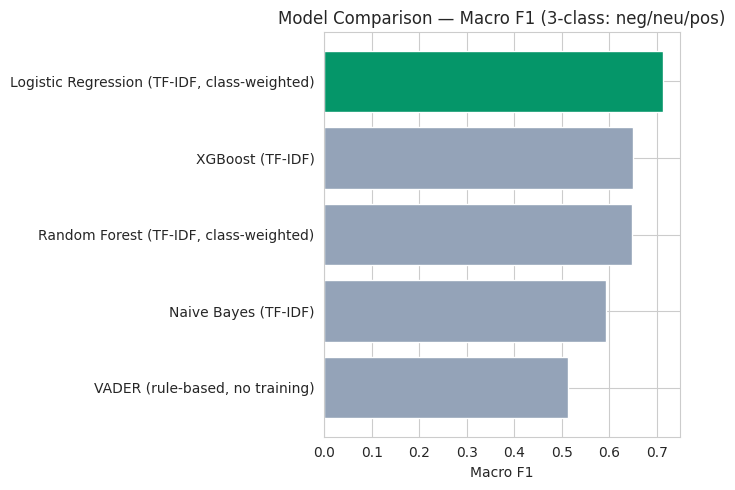

Best model: Logistic Regression (TF-IDF, class-weighted)


In [16]:
results_sorted = results.sort_values("Macro_F1")
colors = ["#94A3B8" if m != results_sorted.iloc[-1]["model"] else "#059669" for m in results_sorted["model"]]

plt.figure(figsize=(7, 5))
plt.barh(results_sorted["model"], results_sorted["Macro_F1"], color=colors)
plt.xlabel("Macro F1")
plt.title("Model Comparison — Macro F1 (3-class: neg/neu/pos)")
plt.tight_layout()
plt.show()

best_model_name = results.sort_values("Macro_F1", ascending=False).iloc[0]["model"]
print(f"Best model: {best_model_name}")


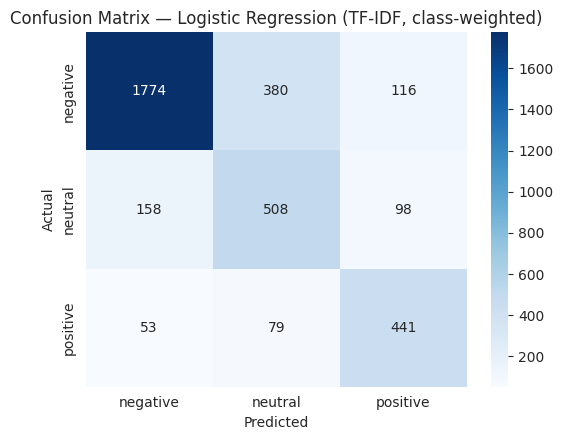

In [17]:
best_preds_map = {
    "VADER (rule-based, no training)": vader_test,
    "Naive Bayes (TF-IDF)": nb_preds,
    "Logistic Regression (TF-IDF, class-weighted)": lr_preds,
    "Random Forest (TF-IDF, class-weighted)": rf_preds,
    "XGBoost (TF-IDF)": xgb_preds,
}
best_preds = best_preds_map[best_model_name]
labels_order = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, best_preds, labels=labels_order)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


## Module 13 — What Words Actually Drive Sentiment?

Using the Logistic Regression coefficients directly — the words most
strongly associated with each class, which is exactly the kind of concrete,
quotable detail a client wants in a report ("customers complain about X").


In [18]:
feature_names = np.array(vectorizer.get_feature_names_out())
neg_idx = list(log_reg.classes_).index("negative")
pos_idx = list(log_reg.classes_).index("positive")

top_neg_words = feature_names[np.argsort(log_reg.coef_[neg_idx])[-15:]][::-1]
top_pos_words = feature_names[np.argsort(log_reg.coef_[pos_idx])[-15:]][::-1]

print("Top words driving NEGATIVE sentiment:")
print(list(top_neg_words))
print("\nTop words driving POSITIVE sentiment:")
print(list(top_pos_words))


Top words driving NEGATIVE sentiment:
['hours', 'worst', 'hold', 'hrs', 'hour', 'delayed', 'rude', 'told', 'cancelled', 'bag', 'luggage', 'disappointed', 'fail', 'customers', 'not_even']

Top words driving POSITIVE sentiment:
['thank', 'thanks', 'great', 'awesome', 'amazing', 'love', 'best', 'kudos', 'thx', 'good', 'excellent', 'appreciate', 'happy', 'wonderful', 'excited']


## Module 14 — Business Insights Summary

In [19]:
worst_airline_pct = sentiment_by_airline.loc[worst_airline, "negative"]
best_airline_pct = sentiment_by_airline.loc[best_airline, "negative"]

print("=== KEY RESULTS ===")
print(results.sort_values("Macro_F1", ascending=False).to_string(index=False))
print(f"\nBest model: {best_model_name}")
print(f"Overall sentiment split: {(sentiment_counts / len(df) * 100).round(1).to_dict()}")
print(f"Worst-performing airline: {worst_airline} ({worst_airline_pct:.1%} negative)")
print(f"Best-performing airline:  {best_airline} ({best_airline_pct:.1%} negative)")
print(f"Top complaint driver: {top_complaint} ({top_pct:.1f}% of negative tweets)")


=== KEY RESULTS ===
                                       model  Accuracy  Macro_F1  Macro_Precision  Macro_Recall
Logistic Regression (TF-IDF, class-weighted)    0.7549    0.7130           0.6974        0.7387
                            XGBoost (TF-IDF)    0.7527    0.6498           0.7193        0.6291
      Random Forest (TF-IDF, class-weighted)    0.6729    0.6476           0.6520        0.6809
                        Naive Bayes (TF-IDF)    0.7366    0.5920           0.7655        0.5524
             VADER (rule-based, no training)    0.5470    0.5129           0.5416        0.6036

Best model: Logistic Regression (TF-IDF, class-weighted)
Overall sentiment split: {'negative': 62.9, 'neutral': 21.2, 'positive': 15.9}
Worst-performing airline: US Airways (77.8% negative)
Best-performing airline:  Virgin America (36.0% negative)
Top complaint driver: Customer Service Issue (31.8% of negative tweets)


## Module 15 — Business Recommendations & Limitations

**Recommendations**

1. **Deploy the best-performing trained model (selected empirically above)
   for ongoing social listening** — it meaningfully outperforms the
   zero-training-cost VADER baseline, which is worth confirming before
   investing in a trained pipeline, not assuming.
2. **Customer service response quality is the single largest lever** —
   it's the top driver of negative sentiment by a wide margin, ahead of
   operational issues like delays or cancellations, meaning it's a
   controllable, trainable factor rather than a purely operational one.
3. **Benchmark competitors, not just yourself** — the gap between the
   best- and worst-performing airline here is enormous; sentiment analysis
   is far more actionable compared against peers than viewed in isolation.
4. **Use the extracted top words as a lightweight, ongoing "what's changing"
   signal** — a sudden new negative word entering the top list (e.g., a
   specific policy name) is often an early warning of an emerging issue
   before it shows up in aggregate satisfaction scores.

**Limitations & Future Work**

- Neutral-class detection is the hardest of the three (visible in the
  confusion matrix) — neutral tweets are often genuinely ambiguous even to
  a human reader, a known challenge in sentiment analysis broadly.
- This is 2015 airline-specific data; sentiment vocabulary and slang shift
  over time and across industries — a production system should be retrained
  periodically on fresh, in-domain data.
- TF-IDF treats words independently of order/context beyond bigrams; a
  transformer-based embedding model (e.g., DistilBERT) would likely improve
  accuracy further, at higher compute cost — a natural next iteration.
- No hyperparameter search was run — parameters used are reasonable
  defaults, not tuned.
- Negation is handled by merging a negation word with the following word
  into one token (Module 4) — this measurably helps common patterns like
  "not bad" or "no issues," but rare negated phrases that appear only a few
  times in training data (e.g. "wouldn't recommend") still don't get enough
  signal to be learned reliably. A larger training set or a proper sequence
  model (LSTM/transformer, which reads negation in context rather than as
  isolated tokens) would close this specific gap further.
